### **Problem 10.1**
Compute, by hand, the second-degree Lagrange polynomial for the points, $x = {0, 2, 4}$ and $f(x) = {1, 0.223891,−0.39715}$. If $f(3) = −0.260052$, how accurate is the interpolation at this point. Plot your interpolating polynomial for $x ∈ [0, 5]$. The points were generated from the Bessel function of the first kind, $J_0(x)$. Compare your interpolating polynomial to the actual function.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0


def quadratic_interp(a,f,x):
    """Compute the quadratic interpolant
    Args:
        a: array of the 3 points
        f: array of the value of f(a) at the 3 points
    Returns:
        The value of the quadratic interpolant at x
    """
    answer = (x-a[1])*(x-a[2])/(a[0]-a[1])/(a[0]-a[2])*f[0]
    answer += (x-a[0])*(x-a[2])/(a[1]-a[0])/(a[1]-a[2])*f[1]
    answer += (x-a[0])*(x-a[1])/(a[2]-a[0])/(a[2]-a[1])*f[2]
    return answer


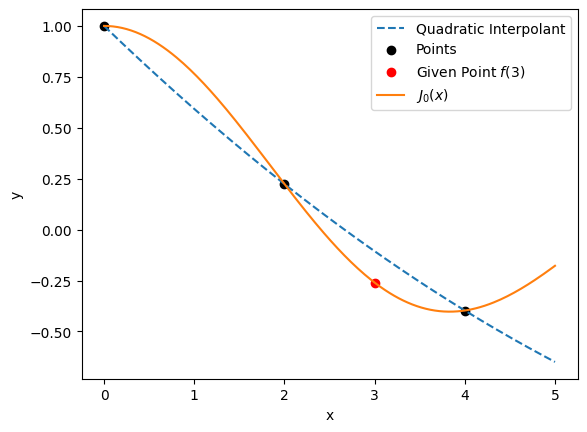

In [2]:
points = np.array([0,2,4])
values = np.array([1, 0.223891, -0.39715])

x = np.linspace(0,5,200)
y = quadratic_interp(points,values,x)

plt.plot(x,y,linestyle="--",label="Quadratic Interpolant")
plt.scatter(points,values,c="black",label="Points")
plt.scatter(3,-0.260052,c="red",label="Given Point $f(3)$")

Bessel = j0(x)
plt.plot(x, Bessel, label="$J_0(x)$")

plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="best")
plt.show()

# The interpolant is not a good approximation at f(3), and when plotted against the Bessel function
# it is unable to capture the oscillations.

### **Problem 10.2**
Repeat the previous exercise with a clamped cubic spline and a not-a-knot cubic
spline.

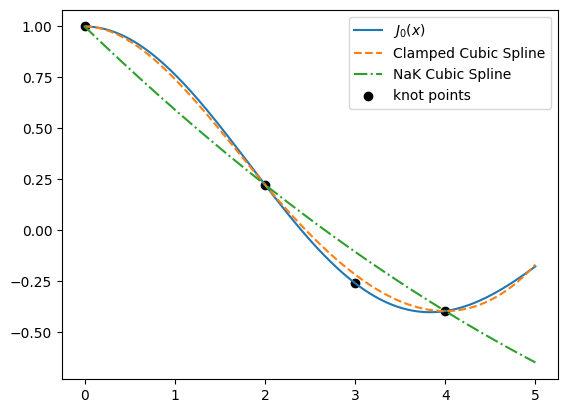

In [3]:
from scipy.interpolate import CubicSpline
#define data
points = np.array([0,2,4])
values = np.array([1, 0.223891, -0.39715])
points2 = np.array([0,2,3,4])
values2 = np.array([1, 0.223891, -0.260052, -0.39715])

#define splines
splineFunction = CubicSpline(points, values, bc_type='natural')
splineFuncClamp = CubicSpline(points, values, bc_type='clamped')
splineFuncNot = CubicSpline(points, values, bc_type='not-a-knot')
#make plot

X = np.linspace(0,5,200)
Bessel = j0(X)

plt.plot(X, Bessel, 
         label="$J_0(x)$")
plt.plot(X,splineFuncClamp(X),linestyle="--",
         label="Clamped Cubic Spline")
plt.plot(X,splineFuncNot(X),linestyle="-.",
         label="NaK Cubic Spline")

plt.scatter(points2, values2, c="black", label="knot points")
plt.legend()

# The NaK Cubic spline seems to be a poor approximation, but the clamped cubic spline is far closer,
# especially given that it captures the oscillations with only 3 data points.

### **Chapter 10, Programming Project 3 - Moderator Temperature Coefficient of Reactivity**

The change in the reactivity for a nuclear reactor due to changes in the moderator temperature is called the moderator temperature coefficient of αm is the logarithmic derivative of $k_∞$ for the reactor as
$$
\alpha_{\mathrm{m}}=\frac{1}{k_{\infty}} \frac{\partial k_{\infty}}{\partial T_{\mathrm{m}}}=-\beta_{\mathrm{m}}\left(\log \frac{1}{p}-(1-f)\right)
$$
where the subscript $m$ denotes “moderator”, $p$ is the resonance escape probability for the
reactor, $f$ is the thermal utilization, and $β_m$ is
$$
\beta_{\mathrm{m}}=-\frac{1}{N_{\mathrm{m}}} \frac{\partial N_{\mathrm{m}}}{\partial T_{\mathrm{m}}}
$$
with $N_m$ the number density of the moderator. 

Consider a research reactor that is cooled by natural convection. It has $p = 0.63$ and $f = 0.94$. Plot the moderator temperature coefficient from $T_m = 285 K$ to $373 K$ as a function of temperature for this reactor, using the data below from the National Institute for Standards and Technology (NIST) for $T_m$ in $K$, and density, $ρ_m$, in mol/liter:

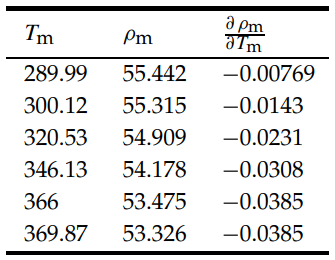

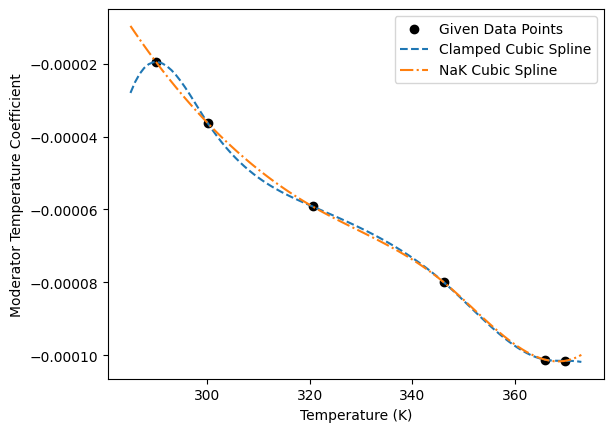

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Given Data:
points_temperature = np.array([289.99, 300.12, 320.53, 346.13, 366, 369.87]) # Temperatures in Kelvin
points_density = np.array([55.442, 55.315, 54.909, 54.178, 53.475, 53.326]) # Densities in mol/liter
points_dP_dT = np.array([-0.00769, -0.0143, -0.0231, -0.0308, -0.0385, -0.0385]) # Derivative of density with respect to temperature

points_numberdensity = points_density * 6.022e23 # Convert density to number density (molecules/liter)
points_dN_dT = points_dP_dT * 6.022e23 # Convert derivative of density to derivative of number density

# Given Constants:
p = 0.63 # Resonance escape probability for the reactor
f = 0.94 # Thermal utilization factor for the reactor

# Equations:
def calculate_aplha(p, f, N, dN_dT):
    beta = -(1/N) * dN_dT # where N is the number density of the moderator
    alpha = -beta * (np.log10(1/p) - (1-f)) # moderator temperature coefficient 
    return alpha

points_alpha = np.zeros_like(points_temperature)
for i in range(len(points_temperature)):
    points_alpha[i] = calculate_aplha(p, f, points_numberdensity[i], points_dN_dT[i])

# Plot the moderature temperature coefficient from T 285K to 373K
temps = np.linspace(285, 373, 100)

splineFuncClamp = CubicSpline(points_temperature, points_alpha, bc_type='clamped')
splineFuncNot = CubicSpline(points_temperature, points_alpha, bc_type='not-a-knot')

plt.scatter(points_temperature, points_alpha, c="black", label="Given Data Points")
plt.plot(temps, splineFuncClamp(temps), linestyle="--",
         label="Clamped Cubic Spline")
plt.plot(temps, splineFuncNot(temps), linestyle="-.",
         label="NaK Cubic Spline")
plt.xlabel("Temperature (K)")
plt.ylabel("Moderator Temperature Coefficient")
plt.legend(loc="best")
plt.show()

### **Chapter 11, Programming Project 1 - Power Law Fit**
Fit a power law to the data below from the United States Internal Revenue Service for the number (in thousands) of tax returns filed in 2014 with particular values of incomes (in thousands). The incomes come from the midpoints of the brackets that the IRS uses to report data. Make the independent variable be the income, and the number of returns be the dependent variable. Compute R2 and the mean absolute error for the model.
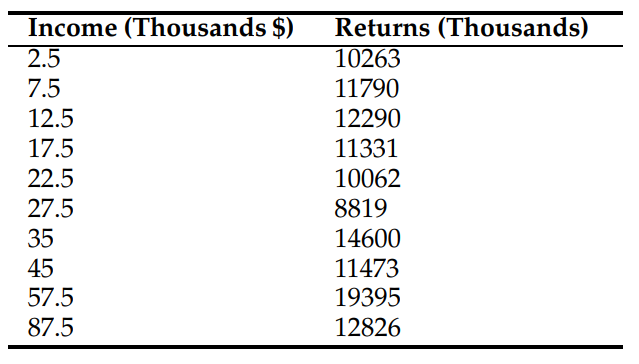
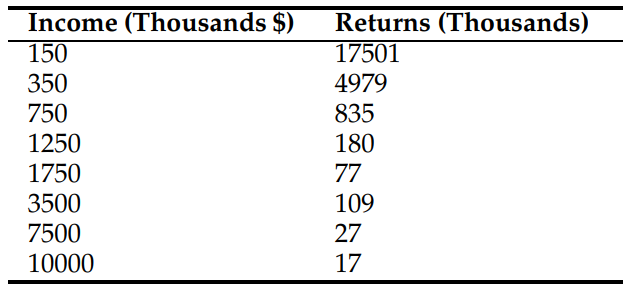

a =  194588.98596637681 , b = -0.8969516971700818
R^2 = -8.204524091455992
R^2 in log-space = 0.8006451887925927
mean abs error = 9230.285487479987 (thousands)


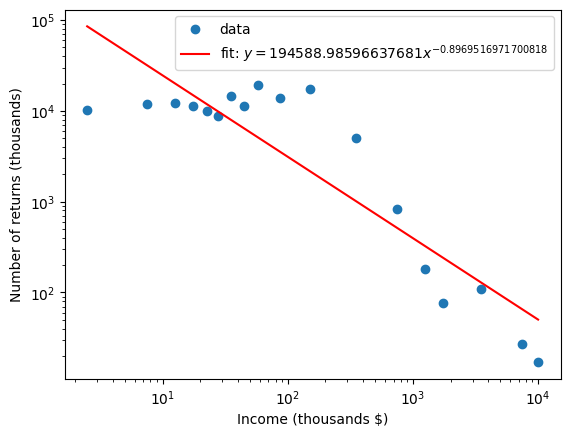

In [23]:
import numpy as np
import matplotlib.pyplot as plt

Data_Income = np.array([2.5,7.5,12.5,17.5,22.5,27.5,35,45,57.5,87.5,150,350,750,1250,1750,3500,7500,10000]) # Income (Thousands $)
Data_Returns = np.array([10263,11790,12290,11331,10062,8819,14600,11473,19395,13826,17501,4979,835,180,77,109,27,17]) # Number of returns (Thousands)
# Fit a power law to the data above with income as the independent variable and number of returns as the dependent variable.

#f(x) = a x**b turns into log(f(x)) = log(a) + b log(x)
log_income = np.log(Data_Income)
log_returns = np.log(Data_Returns)

# linear fit in the log–log space
coeffs = np.polyfit(log_income, log_returns, 1)
b, loga = coeffs # slope and intercept
a = np.exp(loga)              # back out the coefficient of the power law

# predicted values and metrics
pred_log = np.polyval(coeffs, log_income)
pred_returns = np.exp(pred_log)

SS_res = np.sum((Data_Returns - pred_returns)**2)
SS_tot = np.sum((Data_Returns - Data_Returns.mean())**2)
R2 = 1 - SS_res/SS_tot
mae = np.mean(np.abs(Data_Returns - pred_returns))

SS_res_log = np.sum((log_returns - pred_log)**2)
SS_tot_log = np.sum((log_returns - log_returns.mean())**2)
R2_log = 1 - SS_res_log/SS_tot_log

print("a = ",a,", b =",b)
print("R^2 =", R2)
print("R^2 in log-space =", R2_log)
print("mean abs error =", mae, "(thousands)")

# plot the data and the fitted power law
income_plot = np.linspace(Data_Income.min(), Data_Income.max(), 200)
fit_plot = a * income_plot**b

plt.scatter(Data_Income, Data_Returns, label="data")
plt.plot(income_plot, fit_plot, 'r-', label="fit: $y="+str(a)+"x^{{"+str(b)+"}}$")
plt.xlabel("Income (thousands $)")
plt.ylabel("Number of returns (thousands)")
plt.xscale('log'); plt.yscale('log')
plt.legend()
plt.show()

### **Chapter 11, Programming Project 3 - $k_∞$ and Diffusion Length for a Water Balloon**
Consider a water balloon that you fill with a homogeneous mixture of heavy water and fissile material. You do not know the exact ratio of the water molecules to fissile atoms. However, you can fill the balloon with different amounts of the solution (thereby changing the radius of the sphere). You are able to measure the multiplication factor, $k_{eff}$, at several different balloon radii by pulsing the sphere with a neutron source and observing the subcritical multiplication. You also astutely remember that the 1-group diffusion theory relation between the multiplication factor, the infinite medium multiplication factor ($k_∞$), and the diffusion length, $L$ is
$$
k_{\mathrm{eff}}=\frac{k_{\infty}}{1+L^2 B_g^2}
$$
where $B^2_g$ is the geometric buckling for the system. In this case we have
$$
B_g^2=\frac{\pi^2}{(R+d)^2}
$$
where $d$ is the extrapolation length. If we assume that $d << R$, we can do a linear Taylor expansion around $d = 0$ to write
$$
B_g^2=\frac{\pi^2}{R^2}-\frac{2 \pi^2}{R^3} d
$$
Given the measurement data below, infer the values of $k_∞$, $L$, and $d$. Is the assumption on $d$ correct? What radius will make the reactor critical? Report $R^2$ for your model. Hint: make your regression model have the dependent variable be $\frac{1}{k_{eff}}$.

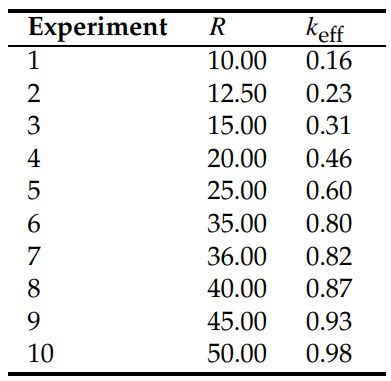

coefficients (C0, C1, C2) = [   0.79254497  562.54479463 -157.3114882 ]
k_inf = 1.2617580542094866
L = 8.480407575885692 (L^2 = 71.91731265313945 )
d = 0.13982129930147996
R^2 of fit = 0.9999204862232686
approximate critical radius (no d) R = 52.073476312387925
d relative to smallest radius = 0.013982129930147996


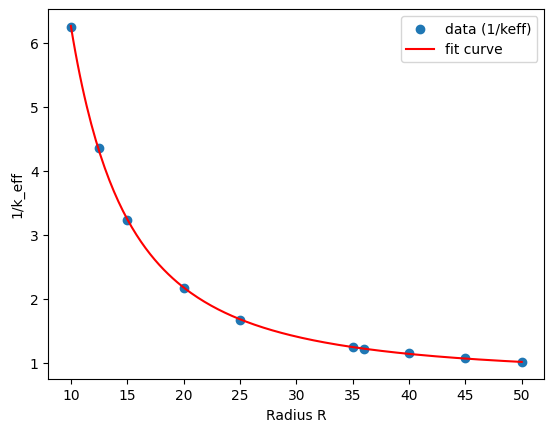

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# data
R = np.array([10,12.5,15,20,25,35,36,40,45,50])   # radii
keff = np.array([0.16,0.23,0.31,0.46,0.60,0.80,0.82,0.87,0.93,0.98])

# dependent variable
y = 1.0/keff # 1/k_eff, like book suggests

# build the design matrix from R (independent variable)
# the physics gives:
# 1/k_eff = 1/k_inf + (L^2 π^2 / k_inf) 1/R^2 - (2 L^2 π^2 d / k_inf) 1/R^3
X = np.column_stack((np.ones_like(R), 1.0/R**2, 1.0/R**3))

# linear least‑squares fit
coeffs = np.linalg.lstsq(X, y, rcond=None)[0]
C0, C1, C2 = coeffs

# recover physical parameters
k_inf = 1.0/C0
L2 = C1 * k_inf / (np.pi**2)      # L^2 = (C1 k_inf)/π^2
L = np.sqrt(L2)
d = -C2 * k_inf / (2 * L2 * np.pi**2)   # from C2 = -2 L^2 π^2 d / k_inf

# statistics
y_pred = X.dot(coeffs)
SS_res = np.sum((y - y_pred)**2)
SS_tot = np.sum((y - y.mean())**2)
R2_model = 1 - SS_res/SS_tot

# critical radius neglecting d
R_crit = np.pi * L / np.sqrt(k_inf - 1)

print("coefficients (C0, C1, C2) =", coeffs)
print("k_inf =", k_inf)
print("L =", L, "(L^2 =", L2, ")")
print("d =", d)
print("R^2 of fit =", R2_model)
print("approximate critical radius (no d) R =", R_crit)
print("d relative to smallest radius =",d / R.min())

# compute a smooth predictive curve
R_fit = np.linspace(R.min(), R.max(), 200)
y_fit = C0 + C1/R_fit**2 + C2/R_fit**3

# plot vs the actual independent variable R
plt.figure()
plt.scatter(R, y, label="data (1/keff)")
plt.plot(R_fit, y_fit, 'r-', label="fit curve")
plt.xlabel("Radius R")
plt.ylabel("1/k_eff")
plt.legend()
plt.show()

### **Problem 12.1**
Find a root of cos x using the three methods discussed in this section and an initial interval of [0, 10]. Compare the solutions and the number of iterations to find the root for each method.

In [35]:
import numpy as np

def bisection(f,a,b,epsilon=1.0e-6):
    """Find the root of the function f via bisection
    where the root lies within [a,b]
    Args:
        f: function to find root of
        a: left-side of interval
        b: right-side of interval
        epsilon: tolerance

    Returns:
        estimate of root
    """
    assert (b>a)
    fa = f(a)
    fb = f(b)
    
    assert (fa*fb < 0)
    delta = b - a
    #print("We expect",
        #int(np.ceil(np.log(delta/epsilon)/np.log(2))),"iterations")

    iterations = 0
    while (delta > epsilon):
        c = (a+b)*0.5
        fc = f(c)   #this is where the function is evaluated
        if (fa*fc < 0):
            b = c
            fb = fc
        elif (fb*fc < 0):
            a = c
            fa = fc
        else:
            return c
        delta = b-a
        iterations += 1

    print("It took",iterations,"iterations")
    return c #return midpoint of interval

In [32]:
def false_position(f,a,b,epsilon=1.0e-6):
    """Find the root of the function f via false position
        where the root lies within [a,b]
    Args:
        f: function to find root of
        a: left-side of interval
        b: right-side of interval
        epsilon: tolerance
    Returns:
        estimate of root
    """
    assert (b>a)
    fa = f(a)
    fb = f(b)
    
    assert (fa*fb< 0)
    delta = b - a
    iterations = 0
    residual = 1.0
    while (np.fabs(residual) > epsilon):
        m = (fb-fa)/(b-a)
        c = a - fa/m
        fc = f(c)       #this is where the function is evaluated
        
        if (fa*fc < 0):
            b = c
            fb = fc
        elif (fb*fc < 0):
            a = c
            fa = fc
        else:
            print("It took",iterations,"iterations")
            return c
    
        residual = fc
        iterations += 1

    print("It took",iterations,"iterations")
    return c #return c

In [33]:
def ridder(f,a,b,epsilon=1.0e-6):
    """Find the root of the function f via Ridder’s Method
        where the root lies within [a,b]
    Args:
        f: function to find root of
        a: left-side of interval
        b: right-side of interval
        epsilon: tolerance
    Returns:
        estimate of root
    """
    assert (b>a)
    fa = f(a)
    fb = f(b)
    assert (fa*fb < 0)
    delta = b - a
    iterations = 0
    residual = 1.0
    while (np.fabs(residual) > epsilon):
        c = 0.5*(b+a)
        d = 0.0
        fc = f(c)                                   #this is where the function is evaluated 1st
        if (fa - fb > 0):
            d = c + (c-a)*fc/np.sqrt(fc**2-fa*fb)
        else:
            d = c - (c-a)*fc/np.sqrt(fc**2-fa*fb)
        fd = f(d)                                   #this is where the function is evaluated again
        #now see which part of interval root is in
        if (fa*fd < 0):
            b = d
            fb = fd
        elif (fb*fd < 0):
            a = d
            fa = fd
        
        residual = fd
        iterations += 1

    print("It took",iterations,"iterations")
    return d #return c

In [42]:
# Finding root of cos(x) using bisection, false position, and Ridder's method.

print("Bisection method:")
bisection_root = bisection(np.cos, 0, 10)
print(bisection_root)
print(" ")

print("False position method:")
false_position_root = false_position(np.cos, 0, 10)
print(false_position_root)
print(" ")

print("Ridder's method:")
ridder_root = ridder(np.cos, 0, 10)
print(ridder_root)
print(" ")

# They all give very similar roots
# Falso position takes the least iterations, and bisection takes the most




Bisection method:
It took 24 iterations
7.853981852531433
 
False position method:
It took 6 iterations
7.853981633974506
 
Ridder's method:
It took 17 iterations
7.853981131825425
 


### **Problem 12.2**
You are given a radioactive sample with an initial specific activity of $10^4$ Bq/kg, and you are told the half-life is 19 days. Compute the time it will take to get the specific activity of Brazil nuts (444 Bq/kg) using the three methods specified above.

In [46]:
# A = λN
# λ = ln(2)/T_half

A0 = 10e4 # initial activity in Bq/kg
targetA = 444 # target activity in Bq/kg
T_half = 19.0 # half-life in days

lam = np.log(2) / T_half

def activity(t):
    return A0 * np.exp(-lam * t)
def residual(t):
    return activity(t) - targetA

a = 0.0
b = 200.0  

print("Bisection method:")
t_bis = bisection(residual, a, b) 
print("t ~", t_bis, "days\n")

print("False‑position method:")
t_fp = false_position(residual, a, b)
print("t ~", t_fp, "days\n")

print("Ridder’s method:")
t_rid = ridder(residual, a, b)
print("t ~", t_rid, "days\n")

# Interestingly, here false position takes teh most and ridders takes the least.


Bisection method:
It took 28 iterations
t ~ 148.4892673790455 days

False‑position method:
It took 867 iterations
t ~ 148.48926761451568 days

Ridder’s method:
It took 5 iterations
t ~ 148.4892675536474 days



### **Problem 13.1**
Apply Newton’s method to the function $f (x) = (1 − x)^2 + 100(1 − x^2)^2 = 0$, using the initial guess of 2.5.

In [55]:
import numpy as np

def newton(f,fprime,x0,epsilon=1.0e-6, LOUD=False):
    """Find the root of the function f via Newton-Raphson method
    Args:
        f: function to find root of
        fprime: derivative of f
        x0: initial guess
        epsilon: tolerance
    Returns:
        estimate of root
    """
    x = x0
    if (LOUD):
        print("x0 =",x0)
        iterations = 0
        fx = f(x)
    while (np.fabs(fx) > epsilon):
        fprimex = fprime(x)
        if (LOUD):
            print("x_",iterations+1,"=",x,"-",fx,
                "/",fprimex,"=",x - fx/fprimex)
        x = x- fx/fprimex
        iterations += 1
        fx = f(x)
    
    print("It took",iterations,"iterations")
    return x #return estimate of root

def inexact_newton(f,x0,delta = 1.0e-7, epsilon=1.0e-6, LOUD=False):
    """Find the root of the function f via Newton-Raphson method
        Args:
            f: function to find root of
            x0: initial guess
            delta: finite difference parameter
            epsilon: tolerance
        Returns:
            estimate of root
    """
    x = x0
    if (LOUD):
        print("x0 =",x0)
    iterations = 0
    fx = f(x)
    while (np.fabs(fx) > epsilon):
        fxdelta = f(x+delta)
        slope = (fxdelta - fx)/delta
        if (LOUD):
            print("x_",iterations+1,"=",x,"-",fx,"/",slope,"=",
        x - fx/slope)
        x = x - fx/slope
        fx = f(x)
        iterations += 1
    
    print("It took",iterations,"iterations")
    return x #return estimate of root


# We will use inexact Newton's method, as only a single function was given

fx = lambda x: (1-x)**2 + 100*(1-x**2)**2

root = inexact_newton(fx, 2.5)
print("Root is approximately at x =", root)

It took 17 iterations
Root is approximately at x = 1.0000301292644713
